# Import necessary libraries

In [ ]:
# do
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interact_manual
%matplotlib inline
from numpy.fft import fft, fftshift, fftfreq, ifft, ifftshift
pi = np.pi

# Task 1: 1D Fourier Transform

Define a function $2\cos(2\pi f_1n) + 3\cos(2\pi f_2n)$

In [ ]:
# Here,
# f2 = 0.2 cycles per sample
# f1 = 0.3 cycles per sample
# n = 0 to N-1
# N = 100

# freq = cycle/sample

N = 100

f1 = 0.3  # n_cycles_1/N
f2 = 0.2  # n_cycles_2/N

n_cycles_1 = f1*N  # 30
n_cycles_2 = f2*N  # 20

n = np.arange(N)

x = (2*np.cos(2*np.pi*f1*n)) + (3*np.cos(2*np.pi*f2*n))

Text(0.5, 1.0, 'Magnitude of X [normalized]')

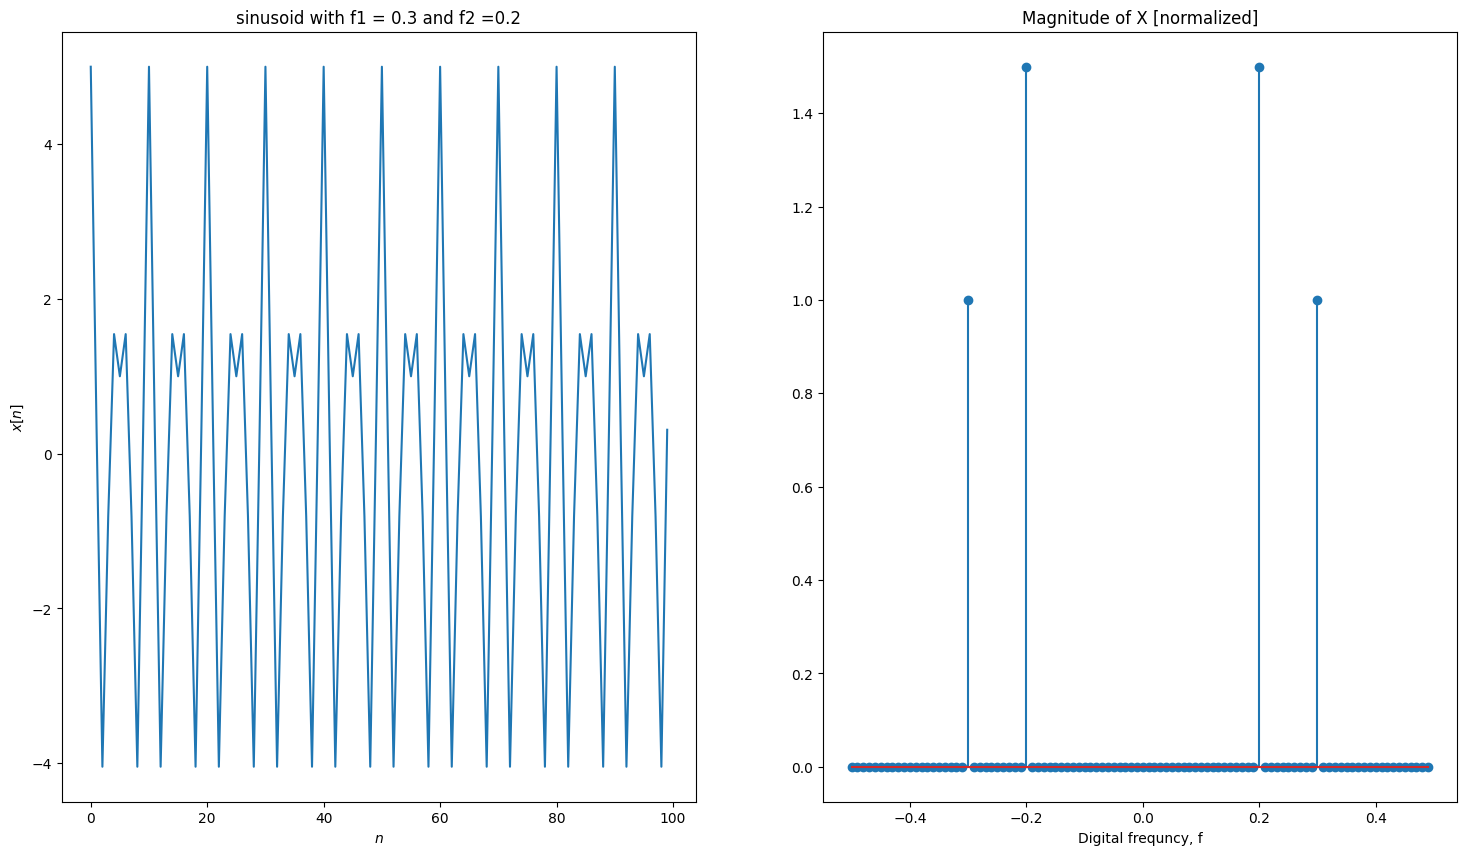

In [ ]:
# perform the fourier transform of the signal
# plot the signal and it's fourier magnitude spectrum side by side

X = fftshift(fft(x))/N

fk = fftshift(fftfreq(N))


fig = plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
plt.plot(n, x)
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.title(f"sinusoid with f1 = {f1} and f2 ={f2}")

plt.subplot(1, 2, 2)
plt.stem(fk, np.abs(X))
plt.xlabel("Digital frequncy, f")
plt.title("Magnitude of X [normalized]")

# Task 2: IFFT

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2355660393.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$x_{\mathrm{recon}}[n]$")


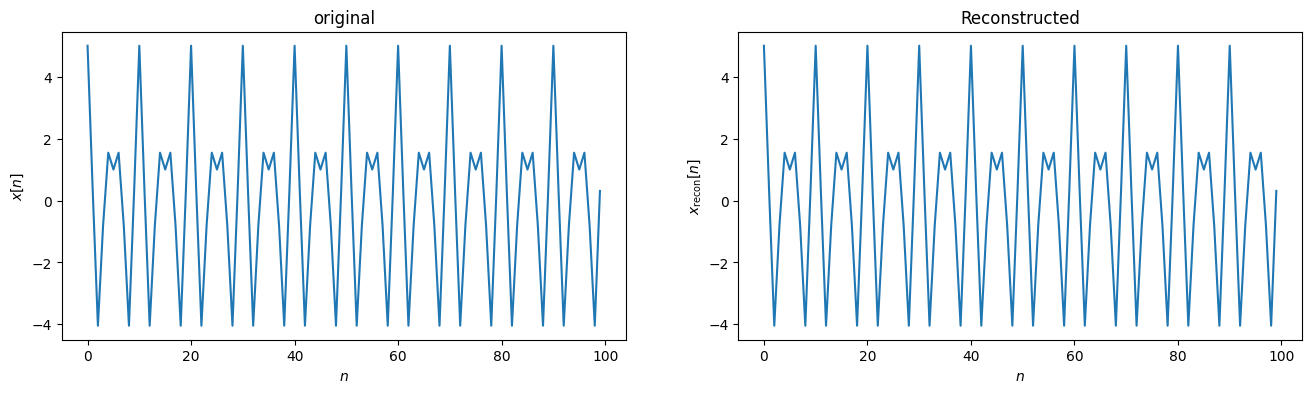

In [ ]:
# performt the inverse fourier transform of X
# plot the original signal and the recosntructed signal side by side
x_recon = np.real(ifft(ifftshift(X))) * N
n_recon = np.arange(len(x_recon))

if x_recon.shape[0] > N:
  x_recon = x_recon[:N]

fig = plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(n, x)
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.title(f"original")

plt.subplot(1, 2, 2)
plt.plot(n_recon, x_recon)
plt.xlabel("$n$")
plt.ylabel("$x_{\mathrm{recon}}[n]$")
plt.title("Reconstructed")
plt.show()

# Task 3: Changing resolution

Text(0.5, 1.0, 'Magnitude of X [normalized] high resolution')

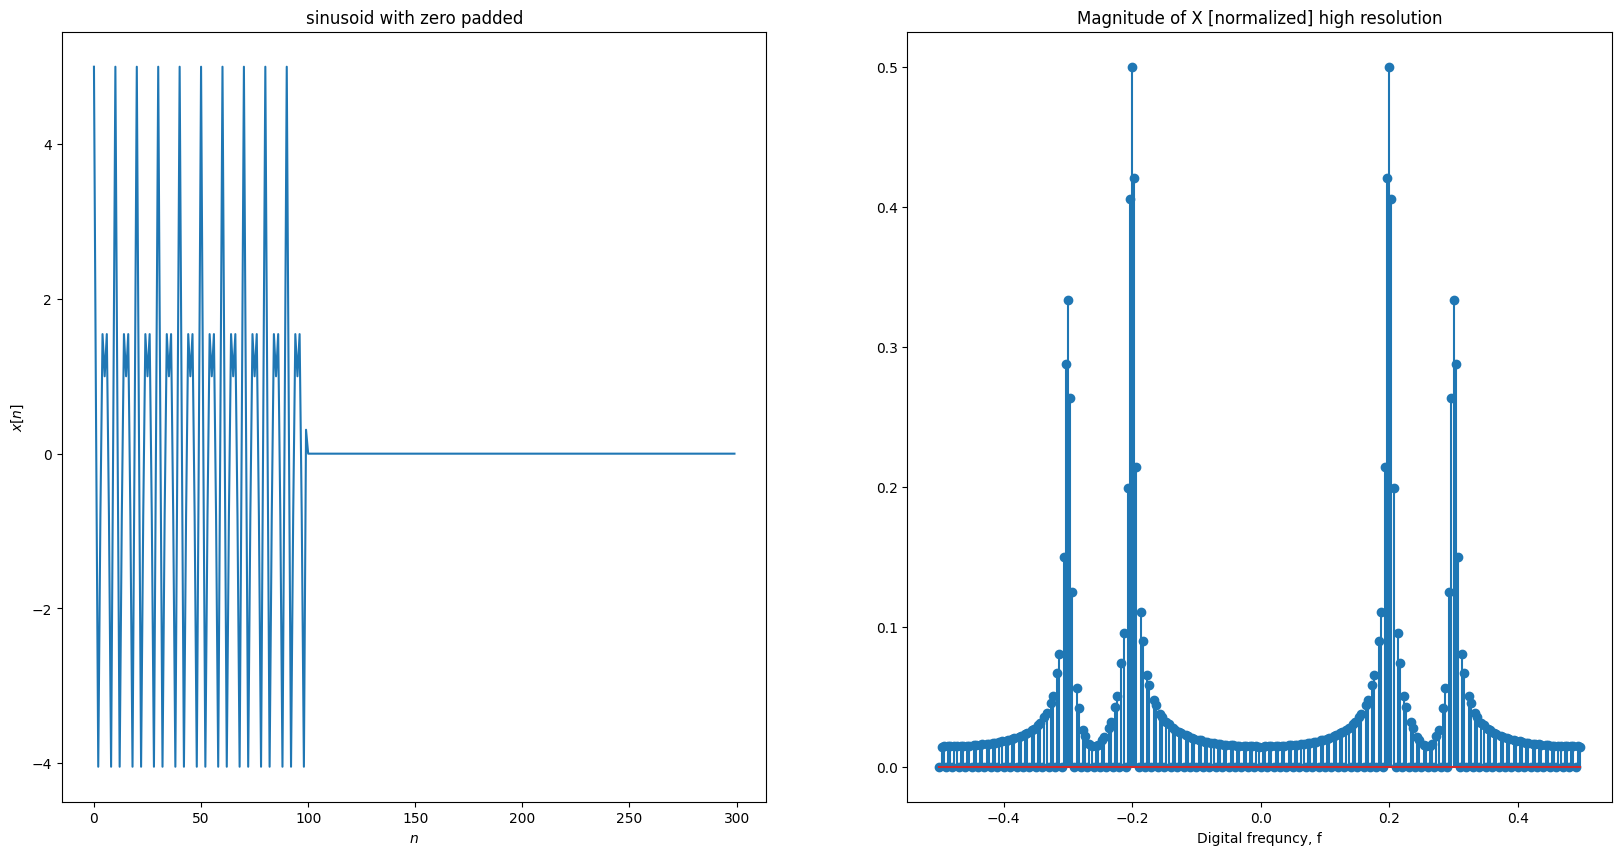

In [ ]:
# perform fourier transform of x again, but this time triple the frequency resolution
# plot the signal and it's fourier magnitude spectrum side by side

N_zeros = 2*N

x_padded = np.concatenate([x, np.zeros(N_zeros)])
n_zero_padded = np.concatenate([n, np.arange(N, N+N_zeros)])



X_high_res= fft(x_padded)
X_high_res = fftshift(X_high_res)
X_high_res = X_high_res/(N+N_zeros)

fk = fftfreq(N+N_zeros)
fk = fftshift(fk)



fig = plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.plot(n_zero_padded, x_padded)
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.title(f"sinusoid with zero padded")

plt.subplot(1, 2, 2)
plt.stem(fk, np.abs(X_high_res))
plt.xlabel("Digital frequncy, f")
plt.title("Magnitude of X [normalized] high resolution")